### 환경설정
- chroma(벡터Db) : 로컬 인메모리 모드지원, 서버불필요
- Neo4j python driver : Neo4j 서버통신
- sentence-transformers : 텍스트 임베딩
- sckit-learn : PCA 데이터 분석 

In [ ]:
!pip install chromadb sentence-transformers neo4j matplotlib networkx scikit-learn -q

In [ ]:
# 설치확인
import chromadb
import neo4j
import sentence_transformers
print(chromadb.__version__, neo4j.__version__, sentence_transformers.__version__)

### 벡터DB
- 고차원벡터(Embedding)를 저장, 유사도검색을 수행하는데 특화
- RAG 핵심 인프라 : LLM의 외부 지식검색에 필수적
- 메타데이터 필터링 : 벡터검색 + 조건 필터링 동시 지원

### 벡터DB 종류
- Chroma : 경량                : 학습(프로토타입)
- Pinecone : 관리형 ,고 가용성   : 대용량 프로젝트
- Weaviate : 멀티모달           : 복합검색
- Milvus : 분선처리 GPU         : 대용량 프로젝트
- FAISS : Meta 오픈소스, 초고속  : 연구용(벤치마크)

In [ ]:
import chromadb
client = chromadb.Client()  # in-memory
# client = chromadb.PersistentClient(path='./outputs')
client.heartbeat()  # 

### collection  생성
- 벡터들의 논리적 그룹(RDBMS 테이블 개념)
- 거리함수 : cosine(기본)
client

In [ ]:
collection = client.get_or_create_collection(
    name = 'korean_foods',
    metadata={'hnsw:space':'cosine'}
)
print(f'컬렉션 이름 : {collection.name}') 
print(f'현재 문서 수 : {collection.count()}')

In [ ]:
documents = [
    "김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.",
    "불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.",
    "비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹는 음식입니다.",
    "된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 끓인 찌개입니다.",
    "삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 있는 요리입니다.",
    "떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다.",
    "냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다.",
    "잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다.",
    "갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요리입니다.",
    "순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다.",
]

metadatas = [
    {"category": "찌개", "main_ingredient": "돼지고기", "spicy": True},
    {"category": "구이", "main_ingredient": "소고기", "spicy": False},
    {"category": "밥",  "main_ingredient": "채소",   "spicy": True},
    {"category": "찌개", "main_ingredient": "된장",   "spicy": False},
    {"category": "구이", "main_ingredient": "돼지고기", "spicy": False},
    {"category": "분식", "main_ingredient": "떡",     "spicy": True},
    {"category": "면",  "main_ingredient": "메밀",   "spicy": False},
    {"category": "볶음", "main_ingredient": "당면",   "spicy": False},
    {"category": "탕",  "main_ingredient": "소고기", "spicy": False},
    {"category": "찌개", "main_ingredient": "순두부", "spicy": True},
]

ids = [f'food_{i:03d}' for i in range(len(documents))]
print(f'ids = {ids}')

collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)
print(f'{collection.count()}개 문서 추가 완료')
for doc_id, doc in zip(ids,documents):
    print(f'    {doc_id} : {doc[:30]}...')

### 유사도 검색

In [ ]:
query  = '매운 국물 요리가 먹고 싶어요'
results = collection.query(
    query_texts=[query],
    n_results=5  # top_5
)
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    similarity = 1- dist # 코사인거리->유사도 변환    
    print(similarity,doc,meta,dist)

In [ ]:
queries = [
    "고기를 구워서 먹는 음식",
    "시원한 여름 음식 추천해주세요",
    "명절에 먹는 전통 음식",
]

# 각 질문에 대해서 top-3 문장을 출력
for query in queries:
    results = collection.query(
        query_texts=[query],
        n_results=3  # top_5
    )
    print(f'\n질문 : {query}')
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

### 메타데이터 필터링
- 기본 벡터유사도 검색 + 조건필터
- 문맥을 통해 유사한 문장을 찾으면서 특정조건을 만족하는 결과

In [ ]:
# 매운음식만 검색 : 필터를 매운음식중에 국물요리 
results = collection.query(
        query_texts=["따뜻한 국물 요리"],
        n_results=3,  # top_5
        where={'spicy':True}  # 매운 음식만
    )
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

In [ ]:
# 카테고리가 찌개인 음식 
# 카테고리가 구이 인 음식
# 소고기 또는 돼지고기를 사용하고 + 매운 음식이 아닌 것

In [ ]:
results = collection.query(
        query_texts=["고기종류의 음식"],
        n_results=3,  # top_5
        where={
                "$and": [
                    { 'main_ingredient':{"$in":["소고기","돼지고기"]} },
                    { 'spicy':False }
                ]
            }
                
    )
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

### 커스텀 임베딩 모델 사용
- Chroma 기본 임베딩 대신 Sentence-Transformer 다국어 모델을 사용해서 한국어 검색 성능을 향상

In [22]:
from chromadb.utils import embedding_functions
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='jhgan/ko-sroberta-multitask'
)

In [24]:
# 커스텀 임베딩 모델용 컬렉션 생성
client.delete_collection("korean_foods_custom")
collection_custom =  client.get_or_create_collection(
    name = 'korean_foods_custom',
    embedding_function=st_ef,
    metadata={'hnsw:space':"cosine"}
)
# 문서추가
collection_custom.add(
    documents=documents,
    metadatas=metadatas,
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
)
# 기본 vs 커스텀 임베딩
test_query = '뜨끈한 국물이 있는 겨울 음식'
r1 = collection.query(query_texts=[test_query],n_results=3)
r2 = collection_custom.query(query_texts=[test_query],n_results=3,
                             where=                
                    { 'category':{"$in":["찌개","탕"]} },
            
                             )

def showResult(results):
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
            similarity = 1- dist # 코사인거리->유사도 변환            
            print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')   
showResult(r1)
print('\n')
showResult(r2)

유사도(0.7687559127807617) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'main_ingredient': '떡', 'category': '분식', 'spicy': True}
유사도(0.742857813835144) 문서:김치찌개는 돼지고기와 김치를...,메타:{'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'}
유사도(0.6985085010528564) 문서:냉면은 메밀 면을 차가운 육...,메타:{'spicy': False, 'main_ingredient': '메밀', 'category': '면'}


유사도(0.46233463287353516) 문서:순두부찌개는 부드러운 순두부...,메타:{'category': '찌개', 'spicy': True, 'main_ingredient': '순두부'}
유사도(0.43149077892303467) 문서:김치찌개는 돼지고기와 김치를...,메타:{'spicy': True, 'category': '찌개', 'main_ingredient': '돼지고기'}
유사도(0.375876784324646) 문서:된장찌개는 된장을 풀어 두부...,메타:{'category': '찌개', 'spicy': False, 'main_ingredient': '된장'}


### CRUD

In [30]:
# READ  ids로 조회
result = collection.get(ids = ["food_000","food_001"])
result

{'ids': ['food_000', 'food_001'],
 'embeddings': None,
 'documents': ['김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.',
  '불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'category': '찌개', 'main_ingredient': '돼지고기', 'spicy': True},
  {'main_ingredient': '소고기', 'spicy': False, 'category': '구이'}]}

In [29]:
collection.update(
    ids = ["food_000"],
    documents=["김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다."],
    metadatas=[{'main_ingredient': '돼지고기', 'category': '찌개', 'spicy': True}],    
)

In [32]:
print(collection.count())
collection.delete(ids = ['food_009'])
print(collection.count())

10
9


In [ ]:
# 뉴스기사검색
# 카테고리분류 - NLP(자연어 모델로 자동 분류)
# documents + meta정보 생성
# VectorDB 구축(Chroma)
# mini RAG  Retrieval:검색  Augmentation:증강  Generation:생성  

In [56]:
# 네이버 검색 API 예제 - 블로그 검색
import os
import re
import sys
import json
import html
import urllib.request
from datetime import datetime
from dotenv import load_dotenv
load_dotenv(override=True)

def _format_date(pubdate):
    return datetime.strptime(pubdate, "%a, %d %b %Y %H:%M:%S %z").strftime("%Y-%m-%d")

def _format_str(text):
    return html.unescape(re.sub(r'<[^>]+>',"",text))

client_id = os.getenv('NAVER_CLIENT_ID')
client_secret = os.getenv('NAVER_CLIENT_SECETET')

items = []
def getNewsData(searchKeyword, category):
    encText = urllib.parse.quote(searchKeyword)
    url = "https://openapi.naver.com/v1/search/news?query=" + encText # JSON 결과
    # url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id",client_id)
    request.add_header("X-Naver-Client-Secret",client_secret)


    response = urllib.request.urlopen(request)
    rescode = response.getcode()
    if(rescode==200):
        response_body = response.read().decode('utf-8')
        result = json.loads(response_body)

        for row in result.get('items'):
            items.append({
                'title':_format_str(row.get('title')),
                'content':_format_str(row.get('description')),
                'category':category,
                'date':_format_date(row.get('pubDate')),
                'link':row.get('link')
            })         
getNewsData('인공지능','기술')
getNewsData('AI 반도체','기술')
getNewsData('전기차','자동차')
getNewsData('아파트','부동산')
getNewsData('취업','사회')

In [71]:
documents = []; metadatas = []
for row in items:
    documents.append(row.get('content')[:-3])
    metadatas.append(
    {
        'title':row.get('title'),
        'category':row.get('category'),
        'date':row.get('date'),
        'link':row.get('link')
    }
    )

### never news 기반 검색 시스템 mini-RAG

In [76]:
# 크로마DB 객체 생성
# 뉴스컬렉션 생성  - 데이터베이스 테이블
# 기사 추가(컬렉션)
# 크로마DB가 제공하는 리트리버를 이용한 유사도기반의 문장 검색

news_client = chromadb.Client()  # in-memory
try:
    news_client.delete_collection('naver_news_api')
except Exception as e:
    print(e)


st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='jhgan/ko-sroberta-multitask'
)

collection_news =  news_client.get_or_create_collection(
    name = 'naver_news_api',
    embedding_function=st_ef,
    metadata={'hnsw:space':"cosine"}
)
# 문서추가
collection_news.add(
    documents=documents,
    metadatas=metadatas,
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
)

# 문서검색
query = '아파트'
query_filter = {'category':'부동산'}
results = collection_news.query(
    query_texts=[query],
    n_results=3,
    where=query_filter
)
showResult(results)

유사도(0.20002591609954834) 문서:원신흥동 친수1초등학교 개교...,메타:{'link': 'https://n.news.naver.com/mnews/article/656/0000177274?sid=100', 'category': '부동산', 'title': "대전 유성구청장 선거 교육 경쟁…정용래 '독서도시' vs 조원휘 '학교 신...", 'date': '2026-05-26'}
유사도(0.18147391080856323) 문서:㈜한화 건설부문이 아파트 브...,메타:{'date': '2026-05-26', 'category': '부동산', 'link': 'https://n.news.naver.com/mnews/article/014/0005526435?sid=101', 'title': "한화 건설부문, 신규 외관 디자인 '포레나 비스타' 공개…브랜드 정체성..."}
유사도(0.13415312767028809) 문서:서울 여의도 일대 아파트 전...,메타:{'date': '2026-05-26', 'title': '여의도 시범아파트 재건축에 삼성물산 등 7개사 관심', 'link': 'https://news.mtn.co.kr/news-detail/2026052614423534963', 'category': '부동산'}


### 임베딩 시각화
- 문맥이 유사한 documents은 서로 가까이 배치(유사도가 높다)

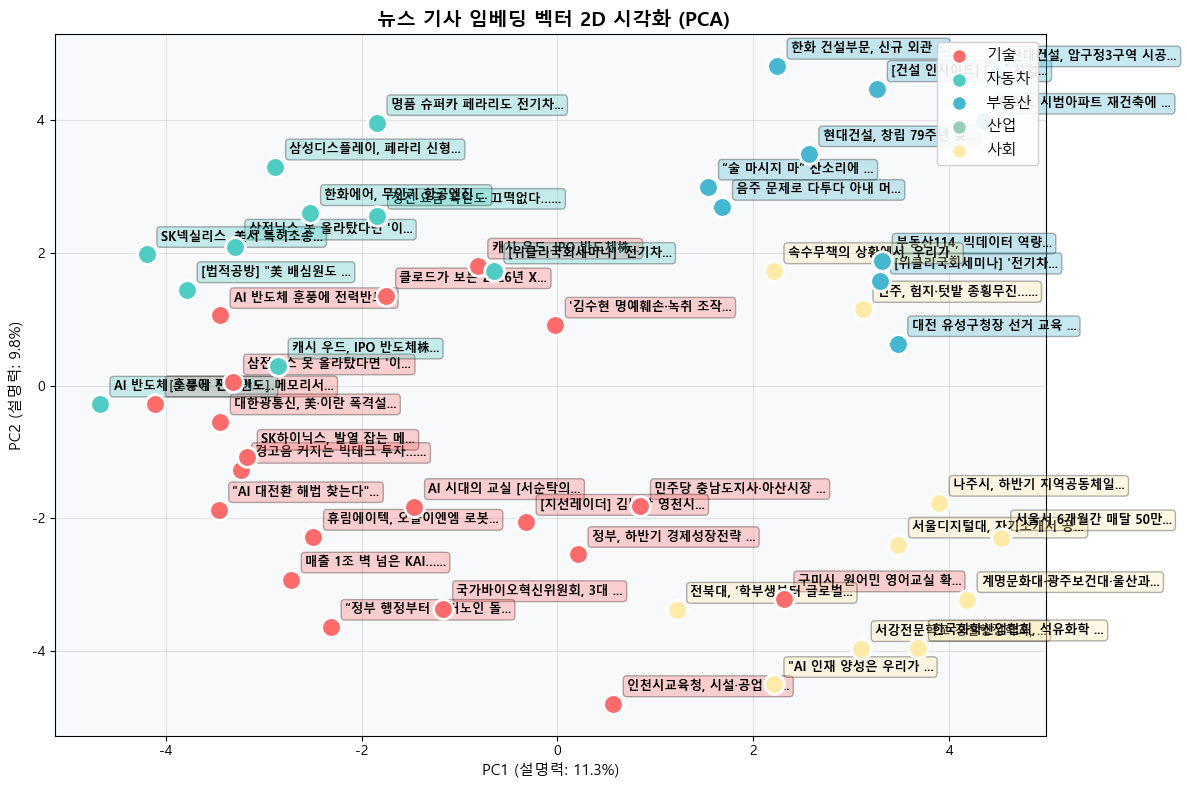


 의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!


In [77]:
# ============================================================
# 임베딩 벡터 2D 시각화 (PCA)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# matplotlib 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 뉴스 기사의 임베딩 벡터 가져오기
all_data = collection_news.get(
    include=["embeddings", "metadatas"]
)

embeddings = np.array(all_data['embeddings'])
categories = [m['category'] for m in all_data['metadatas']]
titles = [m['title'] for m in all_data['metadatas']]

# PCA로 2D 축소
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# 시각화
fig, ax = plt.subplots(figsize=(12, 8))

# 카테고리별 색상
color_map = {
    "기술": "#FF6B6B",
    "자동차": "#4ECDC4",
    "부동산": "#45B7D1",
    "산업": "#96CEB4",
    "사회": "#FFEAA7",
}

for i, (x, y) in enumerate(coords):
    color = color_map.get(categories[i], "#999999")
    ax.scatter(x, y, c=color, s=200, edgecolors='white', linewidths=2, zorder=5)
    # 제목 줄이기
    short_title = titles[i][:15] + "..." if len(titles[i]) > 15 else titles[i]
    ax.annotate(short_title, (x, y), textcoords="offset points",
                xytext=(10, 10), fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

# 범례
for cat, color in color_map.items():
    ax.scatter([], [], c=color, s=100, label=cat, edgecolors='white')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

ax.set_title(' 뉴스 기사 임베딩 벡터 2D 시각화 (PCA)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 (설명력: {pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 (설명력: {pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print("\n 의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!")